In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import zipfile, xml.etree.ElementTree as ET
from pathlib import Path
from scipy.stats import spearmanr


In [6]:
BASE_DIR = Path("/Users/elipieri/repos/SeamStress")

DATASETS = {
    "ethylene":     (r"Ethylene",          "tab:blue"),
    "butadiene_s0": (r"Butadiene S$_0$",   "tomato"),
    "butadiene_s1": (r"Butadiene S$_1$",   "seagreen"),
    "benzene_s0":   (r"Benzene S$_0$",     "darkorange"),
    "benzene_s1":   (r"Benzene S$_1$",     "mediumpurple"),
}

LABEL_SIZE  = 13
TICK_SIZE   = 11
MARKER_S    = 60
MARKER_A    = 0.85

FIG_W       = 4.5      # per-panel width (inches)
FIG_H       = 4.5    # figure height (inches)

OUTPUT_PNG  = str(BASE_DIR / "seam_basin" / "dm_vs_pop_delta.png")
OUTPUT_SVG  = str(BASE_DIR / "seam_basin" / "dm_vs_pop_delta.svg")
OUTPUT_DPI  = 300


In [7]:
def _norm(name):
    return str(name).strip().lower().replace("_", "").replace(" ", "")


def load_meci_data(dataset_name):
    """Return DataFrame with columns: meci, d_m, pop, delta."""
    metrics = pd.read_csv(BASE_DIR / "seam_basin" / dataset_name / "meci_metrics_grid_3d.csv")

    path = BASE_DIR / "data" / dataset_name / "FC_MECI_stats.xlsx"
    ns = "http://schemas.openxmlformats.org/spreadsheetml/2006/main"
    with zipfile.ZipFile(path) as z:
        ss_root = ET.fromstring(z.read("xl/sharedStrings.xml"))
        strings = [si.find(f"{{{ns}}}t").text for si in ss_root.findall(f"{{{ns}}}si")]
        sheet = ET.fromstring(z.read("xl/worksheets/sheet1.xml"))
        raw_rows = []
        for row in sheet.findall(f".//{{{ns}}}row"):
            cells = []
            for c in row.findall(f"{{{ns}}}c"):
                t = c.get("t", "")
                v = c.find(f"{{{ns}}}v")
                if v is None:
                    cells.append("")
                elif t == "s":
                    cells.append(strings[int(v.text)])
                else:
                    cells.append(v.text)
            if any(cells):
                raw_rows.append(cells)

    # Header row has no name column; data rows have name at index 0
    header_lower = [h.lower() for h in raw_rows[0]]
    pop_col   = header_lower.index("pop")   + 1
    delta_col = header_lower.index("delta") + 1

    xlsx = {}
    for row in raw_rows[1:]:
        name = row[0].strip() if row else ""
        if not name:
            continue
        try:
            pop   = float(row[pop_col])   if len(row) > pop_col   and row[pop_col]   not in ("", "-") else None
            delta = float(row[delta_col]) if len(row) > delta_col and row[delta_col] not in ("", "-") else None
        except (ValueError, IndexError):
            pop, delta = None, None
        if pop is not None:
            xlsx[_norm(name)] = {"pop": pop, "delta": delta}

    rows_out = []
    for _, mrow in metrics.iterrows():
        key = _norm(mrow["meci"])
        if key in xlsx:
            rows_out.append({
                "meci":  mrow["meci"],
                "d_m":   mrow["d_m"],
                "pop":   xlsx[key]["pop"],
                "delta": xlsx[key]["delta"],
            })
    return pd.DataFrame(rows_out)


Saved -> /Users/elipieri/repos/SeamStress/seam_basin/dm_vs_pop_delta.png
Saved -> /Users/elipieri/repos/SeamStress/seam_basin/dm_vs_pop_delta.svg


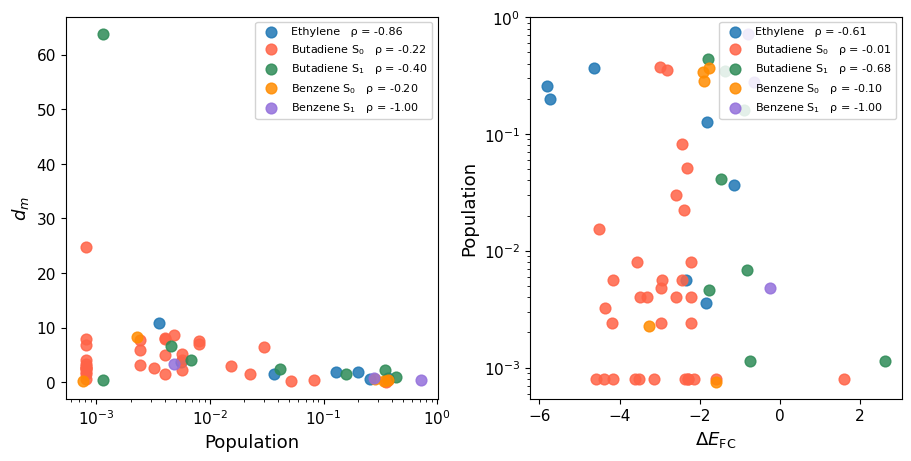

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(FIG_W * 2, FIG_H), constrained_layout=True)

for ds, (label, color) in DATASETS.items():
    df = load_meci_data(ds)
    if df.empty:
        continue

    # ── Left: d_m vs population ───────────────────────────────────────────────
    valid1 = df.dropna(subset=["pop", "d_m"])
    if len(valid1) >= 2:
        rho1, _ = spearmanr(valid1["pop"], valid1["d_m"])
        leg1 = f"{label}   ρ = {rho1:+.2f}"
    else:
        leg1 = label
    ax1.scatter(valid1["pop"], valid1["d_m"],
                color=color, s=MARKER_S, alpha=MARKER_A, label=leg1)

    # ── Right: population vs delta ────────────────────────────────────────────
    valid2 = df.dropna(subset=["delta", "pop"])
    if len(valid2) >= 2:
        rho2, _ = spearmanr(valid2["delta"], valid2["pop"])
        leg2 = f"{label}   ρ = {rho2:+.2f}"
    else:
        leg2 = label
    ax2.scatter(valid2["delta"], valid2["pop"],
                color=color, s=MARKER_S, alpha=MARKER_A, label=leg2)

# ── Left panel formatting ─────────────────────────────────────────────────────
ax1.set_xscale("log")
ax1.set_xlabel("Population", fontsize=LABEL_SIZE)
ax1.set_ylabel(r"$d_m$", fontsize=LABEL_SIZE)
ax1.tick_params(labelsize=TICK_SIZE)
ax1.legend(fontsize=8, framealpha=0.85, loc="upper right")

# ── Right panel formatting ────────────────────────────────────────────────────
ax2.set_yscale("log")
ax2.set_xlabel(r"$\Delta E_\mathrm{FC}$", fontsize=LABEL_SIZE)
ax2.set_ylabel("Population", fontsize=LABEL_SIZE)
ax2.tick_params(labelsize=TICK_SIZE)
ax2.legend(fontsize=8, framealpha=0.85, loc="upper right")

fig.savefig(OUTPUT_PNG, dpi=OUTPUT_DPI, bbox_inches="tight")
fig.savefig(OUTPUT_SVG, dpi=OUTPUT_DPI, bbox_inches="tight")
print(f"Saved -> {OUTPUT_PNG}")
print(f"Saved -> {OUTPUT_SVG}")
plt.show()
